In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import LabelEncoder , OrdinalEncoder # preprocessing -> ön işleme 

In [4]:
df = sns.load_dataset("titanic")

In [5]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [6]:
# cinsiyet , sınıf ve town alıp encode işlemleri yapalım --->

In [7]:
df[["sex","class","embark_town"]].isnull().sum()

sex            0
class          0
embark_town    2
dtype: int64

In [8]:
#df["embark_town"].dropna() ---> diğer bir yolu

df = df.dropna(subset=["embark_town"]) # eksik datalı 2 row tamamen kaldırıldı!

In [9]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [10]:
df[["sex","class","embark_town"]].isnull().sum()

sex            0
class          0
embark_town    0
dtype: int64

# one hot encoding

In [11]:
df["sex"].value_counts()

sex
male      577
female    312
Name: count, dtype: int64

In [12]:
df["class"].value_counts()

class
Third     491
First     214
Second    184
Name: count, dtype: int64

In [13]:
df["embark_town"].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [14]:
df_onehot = pd.get_dummies(df, columns=["sex","embark_town"], drop_first=True)

# pandas fonksiyonu -> get_dummies

In [15]:
df_onehot

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,alive,alone,sex_male,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,S,Third,man,True,NaN,no,False,True,False,True
1,1,1,38.0,1,0,71.2833,C,First,woman,False,C,yes,False,False,False,False
2,1,3,26.0,0,0,7.9250,S,Third,woman,False,NaN,yes,True,False,False,True
3,1,1,35.0,1,0,53.1000,S,First,woman,False,C,yes,False,False,False,True
4,0,3,35.0,0,0,8.0500,S,Third,man,True,NaN,no,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,S,Second,man,True,NaN,no,True,True,False,True
887,1,1,19.0,0,0,30.0000,S,First,woman,False,B,yes,True,False,False,True
888,0,3,NaN,1,2,23.4500,S,Third,woman,False,NaN,no,False,False,False,True
889,1,1,26.0,0,0,30.0000,C,First,man,True,C,yes,True,True,False,False


In [16]:
df_onehot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   survived                 889 non-null    int64   
 1   pclass                   889 non-null    int64   
 2   age                      712 non-null    float64 
 3   sibsp                    889 non-null    int64   
 4   parch                    889 non-null    int64   
 5   fare                     889 non-null    float64 
 6   embarked                 889 non-null    object  
 7   class                    889 non-null    category
 8   who                      889 non-null    object  
 9   adult_male               889 non-null    bool    
 10  deck                     201 non-null    category
 11  alive                    889 non-null    object  
 12  alone                    889 non-null    bool    
 13  sex_male                 889 non-null    bool    
 14  embark_town_Que

In [17]:
# sex kolonu ve embark_town kolonu artık yok! sex kolonu yerine sex_male kolonu gelmiş neden sex_female yok diyebiliriz. sex_male True dediğinde erkek 
# false dediğinde kadın olduğunu anlayabiliriz zaten. Kolondan tasarruf etmiş oluyor.

#Aynı şekilde embark_town için queenstone ve southampton var  cherbourg yok çünkü false-true ve true-false ikililerinde bu iki yerden birisi demek, 
# false-false olduğunda da cherbourg olduğunu anlarız ve yine bir kolondan tasarruf etmiş olduk!

Algoritma şöyle öğreniyor:
1. Eğitim verilerinde şunu görüyor:
Şehir_İstanbul=1, Şehir_Ankara=0, Şehir_İzmir=0 → Fiyat: 800.000₺
Şehir_İstanbul=1, Şehir_Ankara=0, Şehir_İzmir=0 → Fiyat: 750.000₺
Şehir_İstanbul=0, Şehir_Ankara=1, Şehir_İzmir=0 → Fiyat: 400.000₺
Şehir_İstanbul=0, Şehir_Ankara=1, Şehir_İzmir=0 → Fiyat: 450.000₺
2. Algoritma istatistiksel olarak hesaplıyor:

"Şehir_İstanbul=1 olduğunda ortalama fiyat 775.000₺"
"Şehir_Ankara=1 olduğunda ortalama fiyat 425.000₺"

3. Model formülü öğreniyor:
Fiyat = 500.000 + (İstanbul × 275.000) + (Ankara × -75.000) + ...
Yani sen "İstanbul pahalı" demiyorsun ama:

Veri setindeki İstanbul evleri gerçekten pahalı
Algoritma bu gerçek fiyat verilerinden İstanbul'un pahalı olduğunu çıkarıyor
True/False sadece "hangi şehir aktif" bilgisi
Gerçek öğrenme fiyat kolonundan geliyor!

Algoritma patterns (kalıplar) buluyor: "Bu özellik kombinasyonu genelde yüksek fiyatla birlikte görülüyor" 🔍

# label encoder

In [18]:
label_encoder = LabelEncoder()

In [19]:
df_label = df.copy()

In [20]:
df_label

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [21]:
df_label["sex"] = label_encoder.fit_transform(df_label["sex"])

In [22]:
df_label

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,0,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,0,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,1,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [23]:
# görüldüğü gibi label encoder ile sex datalarını (male-female) 0 ve 1 lere çevirdik! male -> 1 , female -> 2

# ordinal encoder

In [24]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [25]:
df_ordinal = df.copy()

In [26]:
class_order = ["Third","Second","First"] # ordinal encoding yaptığımızda categorileri belirlesek daha anlamlı olur buna her zaman dikkat et!

# Third -> 0
# Second -> 1
# First -> 2 verecek çünkü First class en iyi sınıf bu sebeple numaralandırma da mantık sırasına göre uymalı!

In [27]:
ordinal_encoder = OrdinalEncoder(categories=[class_order]) # Burada instance oluşturmadan önce categories'e bizim sınıflandırdığımız class order
#veriyoruz

In [28]:
df_ordinal["class"] = ordinal_encoder.fit_transform(df_ordinal[["class"]])

In [29]:
df_ordinal

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,0.0,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,2.0,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,0.0,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,2.0,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,0.0,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1.0,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,2.0,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,0.0,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,2.0,man,True,C,Cherbourg,yes,True


<Axes: title={'center': 'Class Ordinal Encoded'}, xlabel='class'>

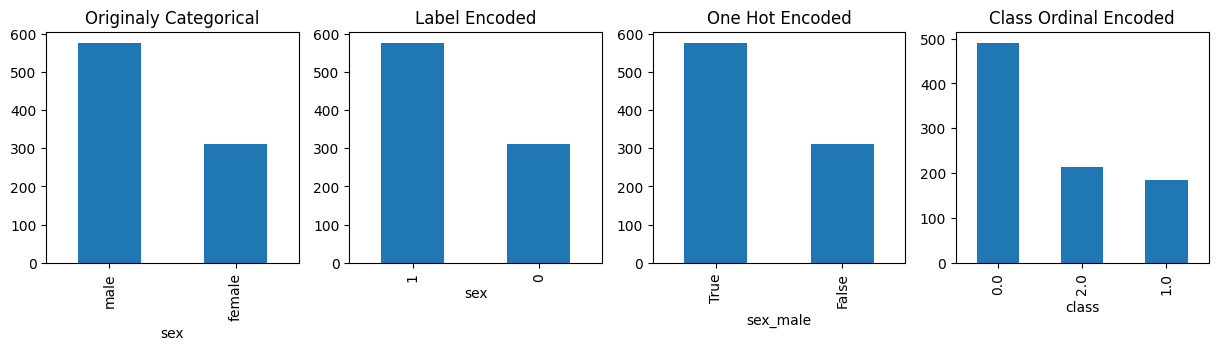

In [30]:
fig , axes = plt.subplots(1,4,figsize =(15,3))
df["sex"].value_counts().plot(kind="bar", ax=axes[0], title="Originaly Categorical")
df_label["sex"].value_counts().plot(kind="bar", ax=axes[1], title="Label Encoded")
df_onehot["sex_male"].value_counts().plot(kind="bar", ax=axes[2], title="One Hot Encoded")
df_ordinal["class"].value_counts().plot(kind="bar", ax=axes[3], title="Class Ordinal Encoded") # class ordinal encoded ->